In [22]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.1
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal



Tf=30
#controller parameters
kp = 0.25#800#1.9e+03 # Proportional gain
kd = 0.5#200#178   # Derivative gain
# crypto parameters
F=GF(next_prime(2^64)) #finite field
server=3 # number of computing servers
t=1 #shamir threshold 
scale=3 # A/D and D/A Accuracy

#initial values
theta2=0.2
theta2dot,theta1,theta1dot=0,0,0
Theta2=[0.2]
Theta2dot=[0]
Theta1=[0]
Theta1dot=[0]
u=0
dt=0.1
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(1,samp):
    
    theta2=0.995459788246996*theta2+0.099668946382836*theta2dot+0.004540211753004*theta1+0.000331053617164*theta1dot+0.000009778468527*u
    theta2dot=-0.090668615329219*theta2+0.991872897970236*theta2dot+0.090668615329219*theta1+0.008127102029764*theta1dot+0.000331053617164*u
    theta1=0.000454021175300*theta2+0.000033105361716*theta2dot+0.999545978824700*theta1+0.099966894638284*theta1dot+0.004999022153147*u
    theta1dot=0.009066861532922*theta2+0.000812710202976*theta2dot-0.009066861532922*theta1+0.999187289797024*theta1dot+0.099966894638284*u
    Theta2.append(theta2)
    Theta2dot.append(theta2dot)
    Theta1.append(theta1)
    Theta1dot.append(theta1dot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()


r=1
theta2c=0.2
theta2cdot,theta1c,theta1cdot=0,0,0
Theta2c=[0.2]
Theta2cdot=[0]
Theta1c=[0]
Theta1cdot=[0]
e,e_prev,u_pd,u_pd_prev,u_n,u_n_prev=0,0,0,0,0,0
U_pd=[0]
U_n=[0]
error=[0]

#CONTROLLED SYSTEM
for i in range(1,samp):
    e=r-theta2c
    u_pd=0.25*e+0.5*(error[i-2]-4*error[i-1]+3*e)/(2*dt)
    if len(U_n)>1:
        u_n=0.4785*U_n[i-1]-0.006738*U_n[i-2]+125.5*u_pd-250*U_pd[i-1]+125.5*U_pd[i-2]
    else:
        u_n=0.4785*U_n[i-1]+125.5*u_pd-250*U_pd[i-1]
    u_c=u_n
    #u_c=u_n
    theta2c=0.995459788246996*theta2c+0.099668946382836*theta2cdot+0.004540211753004*theta1c+0.000331053617164*theta1cdot+0.000009778468527*u_c
    theta2cdot=-0.090668615329219*theta2c+0.991872897970236*theta2cdot+0.090668615329219*theta1c+0.008127102029764*theta1cdot+0.000331053617164*u_c
    theta1c=0.000454021175300*theta2c+0.000033105361716*theta2cdot+0.999545978824700*theta1c+0.099966894638284*theta1cdot+0.004999022153147*u_c
    theta1cdot=0.009066861532922*theta2c+0.000812710202976*theta2cdot-0.009066861532922*theta1c+0.999187289797024*theta1cdot+0.099966894638284*u_c

    U_n.append(u_n)
    U_pd.append(u_pd)
    error.append(e)
    Theta2c.append(theta2c)
    Theta2cdot.append(theta2cdot)
    Theta1c.append(theta1c)
    Theta1cdot.append(theta1cdot)
    


##Secure controlled system

rs=1
theta2cs=0.2
theta2csdot,theta1cs,theta1csdot=0,0,0
Theta2cs=[0.2]
Theta2csdot=[0]
Theta1cs=[0]
Theta1csdot=[0]
es,us_pd,us_n=0,0,0
us_pd=sss.share(F,us_pd,t,server,scale)
us_n=sss.share(F,us_n,t,server,scale)
Us_pd=[]
Us_n=[]
Us_c=[]
Us_pd.append(us_pd)
Us_n.append(us_n)
errors=[]
es=sss.share(F,es,t,server,scale)
errors.append(es)
kp=sss.share(F,kp,t,server,scale)
kd=sss.share(F,kd,t,server,scale)
rec=sss.basispoly(F,server)
for i in range(1,samp):
    
    es=rs-theta2cs
    es=sss.share(F,es,t,server,scale)
    fpcs=shamirproc.mult(F,kp,es,t,server,scale)
    fdcs=shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,3*es,
    shamirproc.add(F,-4*errors[i-1],errors[i-2],t,server,scale),t,server,scale)))
    u_pd=shamirproc.add(F,fpcs,fdcs,t,server,scale)
    if len(Us_n)>1:
        us_n= shamirproc.add(F,0.4785*Us_n[i-1],shamirproc.add(F,-0.006738*Us_n[i-2]
        ,shamirproc.add(F,125.5*us_pd,shamirproc.add(F,-250*Us_pd[i-1],+125.5*Us_pd[i-2]
         ,t,server,scale),t,server,scale),t,server,scale),t,server,scale)
                                           
       # us_n=0.4785*Us_n[i-1]-0.006738*Us_n[i-2]+125.5*us_pd-250*Us_pd[i-1]+125.5*Us_pd[i-2]
    else:
        us_n= shamirproc.add(F,0.4785*Us_n[i-1],shamirproc.add(F,125.5*us_pd,-250*Us_pd[i-1]
            ,t,server,scale) ,t,server,scale)                                    
      #  us_n=0.4785*Us_n[i-1]+125.5*us_pd-250*Us_pd[i-1]
    us_c=sss.rec(F,us_n,rec,scale)
    
    theta2cs=0.995459788246996*theta2cs+0.099668946382836*theta2csdot+0.004540211753004*theta1cs+0.000331053617164*theta1csdot+0.000009778468527*us_c
    theta2csdot=-0.090668615329219*theta2cs+0.991872897970236*theta2csdot+0.090668615329219*theta1cs+0.008127102029764*theta1csdot+0.000331053617164*us_c
    theta1cs=0.000454021175300*theta2cs+0.000033105361716*theta2csdot+0.999545978824700*theta1cs+0.099966894638284*theta1csdot+0.004999022153147*us_c
    theta1csdot=0.009066861532922*theta2cs+0.000812710202976*theta2csdot-0.009066861532922*theta1cs+0.999187289797024*theta1csdot+0.099966894638284*us_c

    Us_n.append(us_n)
    Us_pd.append(us_pd)
    errors.append(es)
    Us_c.append(us_c)                                     
    Theta2cs.append(theta2cs)
    Theta2csdot.append(theta2csdot)
    Theta1cs.append(theta1cs)
    Theta1csdot.append(theta1csdot)




error.pop(0)
#errors.pop(0)
#print(U_pd)
samples2=np.resize(samples, samples.size - 1)
Theta1c.pop(0)
Theta1cs.pop(0)
#print(error)


plt.step(samples,Theta2)
plt.show()
plt.plot(samples,Theta2c)
plt.show()
plt.step(samples,Theta1)
plt.show()
plt.plot(samples2,Theta1c)
plt.show()
plt.plot(samples,U_n)
plt.show()
plt.plot(samples2,error)
plt.show()
plt.plot(samples,Theta2cs)
plt.show()

NameError: name 'GF' is not defined

In [ ]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.1
            
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.1
import numpy as np
from matplotlib import pyplot as plt

Tf=40

#initial values
theta2=0.2
theta2dot,theta1,theta1dot=0,0,0
Theta2=[0.2]
Theta2dot=[0]
Theta1=[0]
Theta1dot=[0]
u=0
dt=0.1
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(1,samp):
    
    theta2=0.995459788246996*theta2+0.099668946382836*theta2dot+0.004540211753004*theta1+0.000331053617164*theta1dot+0.000009778468527*u
    theta2dot=-0.090668615329219*theta2+0.991872897970236*theta2dot+0.090668615329219*theta1+0.008127102029764*theta1dot+0.000331053617164*u
    theta1=0.000454021175300*theta2+0.000033105361716*theta2dot+0.999545978824700*theta1+0.099966894638284*theta1dot+0.004999022153147*u
    theta1dot=0.009066861532922*theta2+0.000812710202976*theta2dot-0.009066861532922*theta1+0.999187289797024*theta1dot+0.099966894638284*u
    Theta2.append(theta2)
    Theta2dot.append(theta2dot)
    Theta1.append(theta1)
    Theta1dot.append(theta1dot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()


r=1
theta2c=0.2
theta2cdot,theta1c,theta1cdot=0,0,0
Theta2c=[0.2]
Theta2cdot=[0]
Theta1c=[0]
Theta1cdot=[0]
e,e_prev,u_pd,u_pd_prev,u_n,u_n_prev=0,0,0,0,0,0
U_pd=[0]
U_n=[0]
error=[0]

#CONTROLLED SYSTEM
for i in range(1,samp):
    e=r-theta2c
    u_pd=0.25*e+0.5*(error[i-2]-4*error[i-1]+3*e)/(2*dt)
    if len(U_n)>1:
        u_n=0.4785*U_n[i-1]-0.006738*U_n[i-2]+125.5*u_pd-250*U_pd[i-1]+125.5*U_pd[i-2]
    else:
        u_n=0.4785*U_n[i-1]+125.5*u_pd-250*U_pd[i-1]
    u_c=u_n
    #u_c=u_n
    theta2c=0.995459788246996*theta2c+0.099668946382836*theta2cdot+0.004540211753004*theta1c+0.000331053617164*theta1cdot+0.000009778468527*u_c
    theta2cdot=-0.090668615329219*theta2c+0.991872897970236*theta2cdot+0.090668615329219*theta1c+0.008127102029764*theta1cdot+0.000331053617164*u_c
    theta1c=0.000454021175300*theta2c+0.000033105361716*theta2cdot+0.999545978824700*theta1c+0.099966894638284*theta1cdot+0.004999022153147*u_c
    theta1cdot=0.009066861532922*theta2c+0.000812710202976*theta2cdot-0.009066861532922*theta1c+0.999187289797024*theta1cdot+0.099966894638284*u_c

    U_n.append(u_n)
    U_pd.append(u_pd)
    error.append(e)
    Theta2c.append(theta2c)
    Theta2cdot.append(theta2cdot)
    Theta1c.append(theta1c)
    Theta1cdot.append(theta1cdot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()
#Theta2c.pop()
#Theta2cdot.pop()
#Theta1c.pop()
#Theta1cdot.pop()
#U_pd.pop()
#U_n.pop()
error.pop(0)
#print(U_pd)
samples2=np.resize(samples, samples.size - 1)
Theta1c.pop(0)
#print(error)

plt.step(samples,Theta2)
plt.show()
plt.plot(samples,Theta2c)
plt.show()
plt.step(samples,Theta1)
plt.show()
plt.plot(samples2,Theta1c)
plt.show()
plt.plot(samples,U_n)
plt.show()
plt.plot(samples2,error)
plt.show()

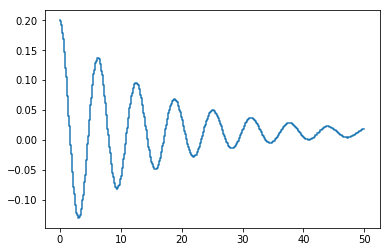

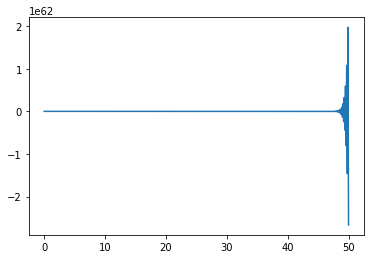

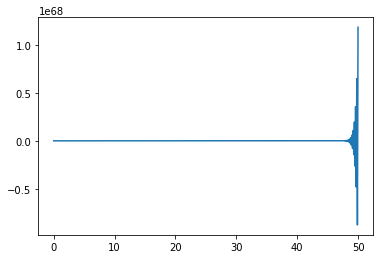

In [121]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.1
            ##########integrated controller
            
import numpy as np
from matplotlib import pyplot as plt

Tf=50

#initial values
theta2=0.2
theta2dot,theta1,theta1dot=0,0,0
Theta2=[0.2]
Theta2dot=[0]
Theta1=[0]
Theta1dot=[0]
u=0
dt=0.1
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(samp):
    
    theta2=0.995459788246996*theta2+0.099668946382836*theta2dot+0.004540211753004*theta1+0.000331053617164*theta1dot+0.000009778468527*u
    theta2dot=-0.090668615329219*theta2+0.991872897970236*theta2dot+0.090668615329219*theta1+0.008127102029764*theta1dot+0.000331053617164*u
    theta1=0.000454021175300*theta2+0.000033105361716*theta2dot+0.999545978824700*theta1+0.099966894638284*theta1dot+0.004999022153147*u
    theta1dot=0.009066861532922*theta2+0.000812710202976*theta2dot-0.009066861532922*theta1+0.999187289797024*theta1dot+0.099966894638284*u
    Theta2.append(theta2)
    Theta2dot.append(theta2dot)
    Theta1.append(theta1)
    Theta1dot.append(theta1dot)
    
Theta2.pop()
Theta2dot.pop()
Theta1.pop()
Theta1dot.pop()


r=1
theta2c=0.2
theta2cdot,theta1c,theta1cdot=0,0,0
Theta2c=[0.2]
Theta2cdot=[0]
Theta1c=[0]
Theta1cdot=[0]
e,e_prev,u_c,u_c_prev=0,0,0,0
U=[0]
error=[0]

#CONTROLLED SYSTEM
for i in range(1,samp):
    e=r-theta2c
    if len(error)>2:
        u_c=643.3*e-1893*error[i-1]+1862*error[i-2]-611.9*error[i-3]-U[i-1]+0.4785*U[i-2]-0.006738*U[i-3]
  #      print(u)
    elif len(error)>1:
        u_c=643.3*e-1893*error[i-1]+1862*error[i-2]-U[i-1]+0.4785*U[i-2]
    else:
        u_c=643.3*e-1893*error[i-1]-U[i-1]
   # print(u_c) 
    theta2c=0.995459788246996*theta2c+0.099668946382836*theta2cdot+0.004540211753004*theta1c+0.000331053617164*theta1cdot+0.000009778468527*u_c
    theta2cdot=-0.090668615329219*theta2c+0.991872897970236*theta2cdot+0.090668615329219*theta1c+0.008127102029764*theta1cdot+0.000331053617164*u_c
    theta1c=0.000454021175300*theta2c+0.000033105361716*theta2cdot+0.999545978824700*theta1c+0.099966894638284*theta1cdot+0.004999022153147*u_c
    theta1cdot=0.009066861532922*theta2c+0.000812710202976*theta2cdot-0.009066861532922*theta1c+0.999187289797024*theta1cdot+0.099966894638284*u_c
    
  #  u_c_prev=u_c
    U.append(u_c)
  #  e_prev=e
    error.append(e)
   # print(error)
    Theta2c.append(theta2c)
    Theta2cdot.append(theta2cdot)
    Theta1c.append(theta1c)
    Theta1cdot.append(theta1cdot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()
#Theta2c.pop()
#Theta2cdot.pop()
#Theta1c.pop()
#Theta1cdot.pop()
#U.pop()
#error.pop()
#print(U_pd)




plt.step(samples,Theta2)
plt.show()
plt.plot(samples,Theta2c)
plt.show()
plt.plot(samples,U)
plt.show()

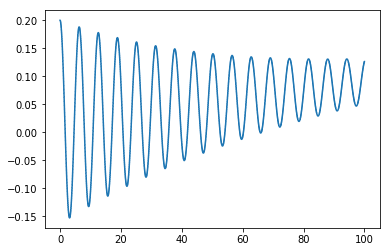

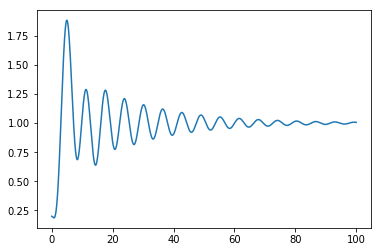

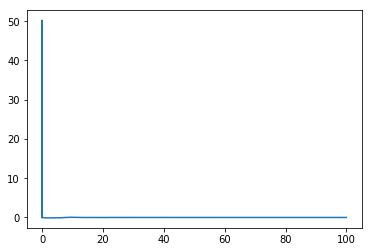

In [73]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.01
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

Tf=100

#initial values
theta2_prev=0.2
theta2dot_prev,theta1_prev,theta1dot_prev=0,0,0
Theta2=[0.2]
Theta2dot=[0]
Theta1=[0]
Theta1dot=[0]
u=0
samp=Tf/0.01
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(samp):
    
    theta2=1*theta2_prev+0.01*theta2dot_prev
    theta2dot=-0.0091*theta2_prev+0.9996*theta2dot_prev+0.0091*theta1_prev+0.0004*theta1dot_prev
    theta1=theta1_prev+0.01*theta1dot_prev
    theta1dot=0.00091*theta2_prev-0.00091*theta1_prev+1*theta1dot_prev+0.01*u
    theta2_prev=theta2
    theta2dot_prev=theta2dot
    theta1_prev=theta1
    theta1dot_prev=theta1dot 
    Theta2.append(theta2)
    Theta2dot.append(theta2dot)
    Theta1.append(theta1)
    Theta1dot.append(theta1dot)
    
Theta2.pop()
Theta2dot.pop()
Theta1.pop()
Theta1dot.pop()


r=1
theta2c_prev=0.2
theta2cdot_prev,theta1c_prev,theta1cdot_prev=0,0,0
Theta2c=[0.2]
Theta2cdot=[0]
Theta1c=[0]
Theta1cdot=[0]
e,e_prev,u_pd,u_pd_prev,u_n,u_n_prev=0,0,0,0,0,0
U_pd=[0]
U_n=[0]
error=[0]

#CONTROLLED SYSTEM
for i in range(samp):
    e=r-theta1c_prev
    u_pd=0.25*e+0.5*(e-e_prev)/0.01
 #   u_pd=50.13*e-49.88*e_prev-u_pd_prev
 #   u_pd=abs(u_pd)
 #   if len(U_n)>1:
#        u_n=1.558*u_n_prev-0.6065*U_n[i-2]+604.1*u_pd-1208*u_pd_prev+604.1*U_pd[i-2] 
 #   else:
 #       u_n=1.558*u_n_prev+604.1*u_pd-1208*u_pd_prev
    theta2c=1*theta2c_prev+0.01*theta2cdot_prev
    theta2cdot=-0.0091*theta2c_prev+0.9996*theta2cdot_prev+0.0091*theta1c_prev+0.0004*theta1cdot_prev
    theta1c=theta1c_prev+0.01*theta1cdot_prev
    theta1cdot=0.00091*theta2c_prev-0.00091*theta1c_prev+1*theta1cdot_prev+0.01*u_pd
    
    theta2c_prev=theta2c
    theta2cdot_prev=theta2cdot
    theta1c_prev=theta1c
    theta1cdot_prev=theta1cdot 
    e_prev=e
    u_pd_prev=u_pd
  #  u_n_prev=u_n
  #  U_n.append(u_n)
    U_pd.append(u_pd)
    error.append(e)
    Theta2c.append(theta2c)
    Theta2cdot.append(theta2cdot)
    Theta1c.append(theta1c)
    Theta1cdot.append(theta1cdot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()
Theta2c.pop()
Theta2cdot.pop()
Theta1c.pop()
Theta1cdot.pop()
U_pd.pop()
U_n.pop()
error.pop()
#print(U_pd)

plt.step(samples,Theta2)
plt.show()
plt.plot(samples,Theta2c)
plt.show()
plt.plot(samples,U_pd)
plt.show()

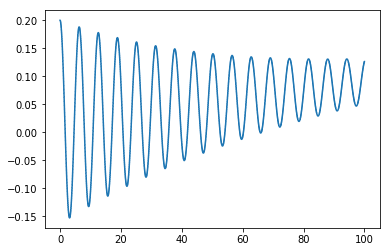

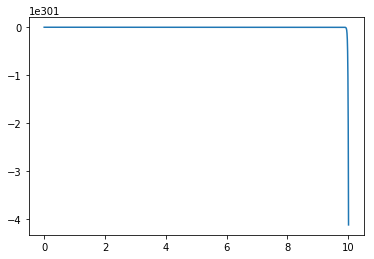

/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/ticker.py:1919: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


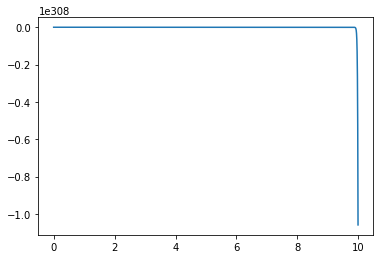

In [3]:
                     ## controlled
                     ########SATELLITE#######
                    ###integrated controller and filter
                        ##T=0.01
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

Tf=100

#initial values
theta2_prev=0.2
theta2dot_prev,theta1_prev,theta1dot_prev=0,0,0
Theta2=[0.2]
Theta2dot=[0]
Theta1=[0]
Theta1dot=[0]
#u=1
samp=Tf/0.01
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(samp):
    
    theta2=1*theta2_prev+0.01*theta2dot_prev
    theta2dot=-0.0091*theta2_prev+0.9996*theta2dot_prev+0.0091*theta1_prev+0.0004*theta1dot_prev
    theta1=theta1_prev+0.01*theta1dot_prev
    theta1dot=0.00091*theta2_prev-0.00091*theta1_prev+1*theta1dot_prev#+0.01*u
    theta2_prev=theta2
    theta2dot_prev=theta2dot
    theta1_prev=theta1
    theta1dot_prev=theta1dot 
    Theta2.append(theta2)
    Theta2dot.append(theta2dot)
    Theta1.append(theta1)
    Theta1dot.append(theta1dot)
    
Theta2.pop()
Theta2dot.pop()
Theta1.pop()
Theta1dot.pop()


r=1
theta2c_prev=0.2
theta2cdot_prev,theta1c_prev,theta1cdot_prev=0,0,0
Theta2c=[0.2]
Theta2cdot=[0]
Theta1c=[0]
Theta1cdot=[0]
e,e_prev,u,u_prev=0,0,0,0
U=[0]
U_n=[0]
error=[0]
#u=1
#CONTROLLED SYSTEM
for i in range(samp):
    e=r-theta2c_prev
    if len(error)>2:
        u=3.30e04*e-9068e04*error[i-1]+9.05e04*error[i-2]-3.01e04*error[i-3]-U[i-1]+1.588*U[i-2]-0.6065*U[i-3]
  #      print(u)
    elif len(error)>1:
        u=3.30e04*e-9068e04*error[i-1]+9.05e04*error[i-2]-3.01e04*error[i-3]-U[i-1]+1.588*U[i-2]
   #     print(u)
    else:
        u=3.30e04*e-9068e04*error[i-1]-U[i-1]
        
    theta2c=1*theta2c_prev+0.01*theta2cdot_prev
    theta2cdot=-0.0091*theta2c_prev+0.9996*theta2cdot_prev+0.0091*theta1c_prev+0.0004*theta1cdot_prev
    theta1c=theta1c_prev+0.01*theta1cdot_prev
    theta1cdot=0.00091*theta2c_prev-0.00091*theta1c_prev+1*theta1cdot_prev+0.01*u
    
    theta2c_prev=theta2c
    theta2cdot_prev=theta2cdot
    theta1c_prev=theta1c
    theta1cdot_prev=theta1cdot 
    e_prev=e
    u_prev=u
   # u_n_prev=u_n
   # U_n.append(u_n)
    U.append(u)
    error.append(e)
    Theta2c.append(theta2c)
    Theta2cdot.append(theta2cdot)
    Theta1c.append(theta1c)
    Theta1cdot.append(theta1cdot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()
Theta2c.pop()
Theta2cdot.pop()
Theta1c.pop()
Theta1cdot.pop()
U.pop()
error.pop()
#print(U_pd)

plt.step(samples,Theta2)
plt.show()
plt.plot(samples,Theta2c)
plt.show()
plt.plot(samples,U)
plt.show()

field cardinality : 257
running time of insecure controller: 0.0010073184967041016
running time of secure controller: 0.02469658851623535
running time of secure /running time of insecure : 24.51715976331361

UNCONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

uncontrolled system constant time :4.5078125
uncontrolled system risingtime :9.9171875
uncontrolled system settlingtime :18.03125

INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Insecure controlled system constant time :5.222638003355236
Insecure controlled system risingtime :5.95841314431245
Insecure controlled system settlingtime :31.836494752527106
Insecure controlled system "peak amplitude :1.23" "overshoot :22.6" "At time :13.0"

SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Secure controlled system constant time :5.268511947007334
Secure controlled system risingtime :5.829095236874997
Secure controlled system settlingtime :68.50911509427699
Secure controlled system "peak amplitude :1.28" "overshoot :27.9"

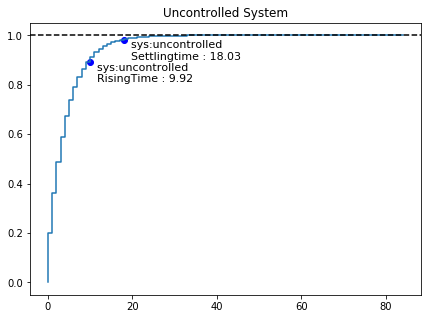

+--------------------------------------------+------------------------------+-----------------------------+
|                                            | Integral Absolute Error(IAE) | Integral Squared Error(ISE) |
+--------------------------------------------+------------------------------+-----------------------------+
|      b-w controlled System responses       |          2.622E-02           |          2.626E-03          |
|            b-w Control signals             |          3.131E-02           |          4.212E-03          |
|             b-w Error signals              |          1.974E-02           |          1.265E-03          |
| b-w controlled System responses with noise |          1.815E-01           |          1.228E-01          |
+--------------------------------------------+------------------------------+-----------------------------+


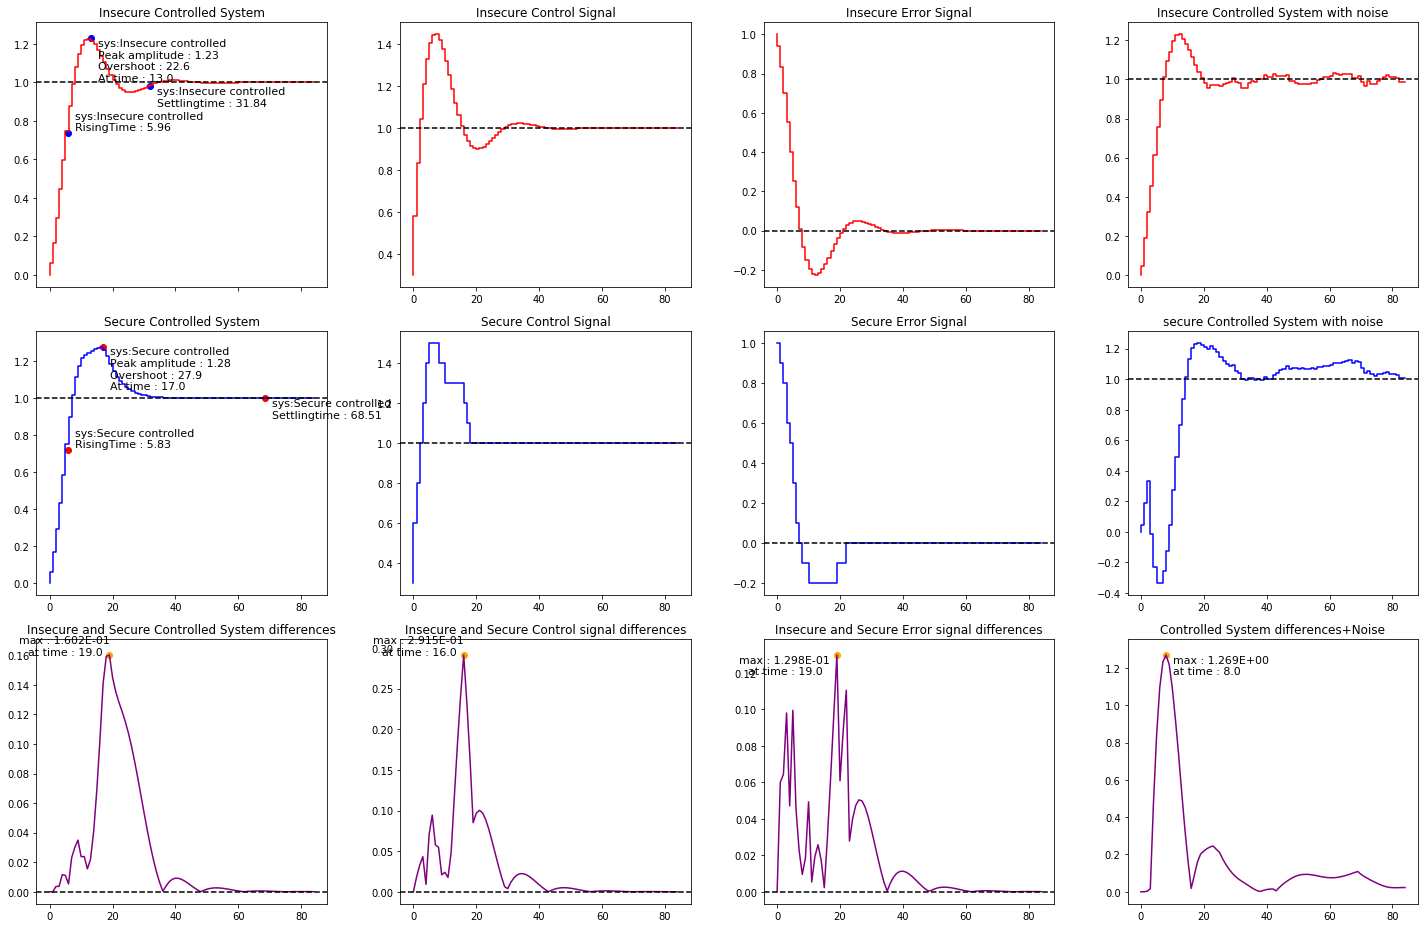

In [7]:
                         ###########CONTROL###########+ rnd NOISE### coeff of e in u computing is publickly known
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal

#number of parties(servers) and finite field and number of samples
server=3 #set number of servers
t=1 #set shamir threshold
sampling=85
F=GF(next_prime(2^8))
scale=1
print('field cardinality : {0}'.format(F.cardinality()))
mu=0  #Mean (“centre”) of the distribution
sigma=0.01 #Standard deviation (spread or “width”) of the distribution. Must be non-negative
#initial values
rk,ek,srk,sek,ekn,rkn,eksn,srkn=1,1,1,1,1,1,1,1
ycont,yuncont,ukminus1,yconts,yunconts,ukminus1s,ycontn,ukminus1n,ycontsn,ukminus1sn=0,0,0,0,0,0,0,0,0,0
insecureU,secureU,Yuncont,Ycont,YNcont,YNscont,Yscont,E,SE=[],[],[0],[0],[0],[0],[0],[],[]
noise=np.random.normal(mu,sigma,sampling)

#UNCONTROLLED SYSTEM
for i in range(sampling):
    yuncont=0.8*yuncont+0.2
    Yuncont.append(yuncont)
    
#INSECURE Cntrol    
tic=time.time()
for i in range(sampling):
    ek = rk-ycont
    uk = ukminus1 + 0.3*ek
    ycont=0.8*ycont + 0.2*uk 
    ukminus1 = uk
    Ycont.append(ycont)
    insecureU.append(uk)
    E.append(ek)
toc=time.time()

#INSECURE Cntrol+Noise    
for i in range(sampling):
    ekn = rkn-ycontn
    ukn = ukminus1n + 0.3*ekn
    ycontn=0.8*ycontn + 0.2*ukn + noise[i]
    ukminus1n = ukn
    YNcont.append(ycontn)


#SECURE Cntrol + Noise (sytem is controlled by parties securely)
r=sss.basispoly(F,server)
#sharing initial value
ukminus1sn=sss.share(F,ukminus1sn,t,server,scale)
srkn=sss.share(F,srkn,t,server,scale)
ycontsn0=sss.share(F,-ycontsn,t,server,scale)
for i in range(sampling):
    #cloud computing part
    eksn =shamirproc.add(F,srkn,ycontsn0,t,server,scale)
    uksn = shamirproc.add(F,ukminus1sn,shamirproc.Idiv(F,3*eksn,10,server,t,r),t,server,scale) #control law (Computed by n servers)
    #center server computing part
    ycontsn=0.8*ycontsn+0.2*(sss.rec(F,uksn,r,scale)) + noise[i]
    ycontsn0=sss.share(F,-ycontsn,t,server,scale)
    ukminus1sn = uksn
    YNscont.append(ycontsn)


#SECURE Cntrol (sytem is controlled by parties securely)
r=sss.basispoly(F,server)
ukminus1s=sss.share(F,ukminus1s,t,server,scale)
srk=sss.share(F,srk,t,server,scale)
yconts0=sss.share(F,-yconts,t,server,scale)
tics=time.time()
for i in range(sampling):
    eks =shamirproc.add(F,srk,yconts0,t,server,scale)
    uks = shamirproc.add(F,ukminus1s,shamirproc.Idiv(F,3*eks,10,server,t,r),t,server,scale) #control law (Computed by n servers)
    yconts=0.8*yconts+0.2*(sss.rec(F,uks,r,scale))
    yconts0=sss.share(F,-yconts,t,server,scale)
    ukminus1s = uks
    Yscont.append(yconts)
    secureU.append(sss.rec(F,uks,r,scale))
    SE.append(sss.rec(F,eks,r,scale))
tocs=time.time()
print('running time of insecure controller: {0}'.format(toc-tic))
print('running time of secure controller: {0}'.format(tocs-tics))
print('running time of secure /running time of insecure : {0}'.format((tocs-tics)/(toc-tic)))
Ycont.pop()
YNcont.pop()
Yscont.pop()
YNscont.pop()
Yuncont.pop()
srk=srkn=rk
#error will be very smaller in the end of secure case because secure conroller compute control signal up to 3 decimal places


samples=[]
for i in range(sampling):
    samples.append(i)

##UNCONTROLLED SYSTEM_STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'UNCONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
funcont = interp1d(Yuncont,samples) #interpolating time with respect to output values
f2uncont = interp1d(samples,Yuncont) #interpolating output values with respect to time
#stepresponse of sys
uncontau = funcont(0.632)
uncontrising=2.2*uncontau
uncontsettling=4*uncontau
tau=print('uncontrolled system constant time :{0}'.format(uncontau))
risingtime = print('uncontrolled system risingtime :{0}'.format(uncontrising)) 
settlingtime = print('uncontrolled system settlingtime :{0}'.format(uncontsettling))
if max(Yuncont)>rk:
    peakampun=round(max(Yuncont),2)
    overshootun=round(((max(Yuncont)-rk)/rk)*100,1)
    peaktimeun=round(funcont(max(Yuncont)),2)
    print('uncontrolled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakampun,overshootun,peaktimeun))

##INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fcont = interp1d(Ycont,samples) 
f2cont=interp1d(samples,Ycont) 
#stepresponse of sys
contau = fcont(0.632*rk)
contrising = fcont(0.85*rk)-fcont(0.05*rk)
contsettling = fcont(0.98*rk)
tau=print('Insecure controlled system constant time :{0}'.format(contau))
risingtime = print('Insecure controlled system risingtime :{0}'.format(contrising)) 
settlingtime = print('Insecure controlled system settlingtime :{0}'.format(contsettling))
if max(Ycont)>rk:
    peakamp=round(max(Ycont),2)
    overshoot=round(((max(Ycont)-rk)/rk)*100,1)
    peaktime=round(fcont(max(Ycont)),2)
    print('Insecure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamp,overshoot,peaktime))

##SECURE STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fscont = interp1d(Yscont,samples)
f2scont = interp1d(samples,Yscont)
#stepresponse of sys
scontau = fscont(0.632*srk)
scontrising = fscont(0.85*srk)-fscont(0.05*srk)
scontsettling = fscont(0.98*srk)
tau=print('Secure controlled system constant time :{0}'.format(scontau))
risingtime = print('Secure controlled system risingtime :{0}'.format(scontrising)) 
settlingtime = print('Secure controlled system settlingtime :{0}'.format(scontsettling))
if max(Yscont)>srk:
    peakamps=round(max(Yscont)/rk,2)
    overshoots=round(((max(Yscont)-rk)/rk)*100,1)
    peaktimes=round(fscont(max(Yscont)),2)
    print('Secure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamps,overshoots,peaktimes))


stepinfo=1 ##### put in one if you want stepinfo######
#plots
#uncontrolled sys
plt.step(samples,Yuncont)
plt.rcParams["figure.figsize"] = (7,5)
plt.title('Uncontrolled System')
plt.axhline(y = 1, color = 'black', linestyle = '--')
if stepinfo==True:
    plt.scatter(uncontrising,f2uncont(uncontrising),color = 'blue')
    plt.scatter(uncontsettling,f2uncont(uncontsettling),color = 'blue')
    plt.text(uncontrising,f2uncont(uncontrising),
             '  sys:uncontrolled\n  RisingTime : {0}'.format(round(uncontrising,2))
             ,verticalalignment='top',fontsize=11)
    plt.text(uncontsettling,f2uncont(uncontsettling),
             '  sys:uncontrolled\n  Settlingtime : {0}'.format(round(uncontsettling,2))
             ,verticalalignment='top',fontsize=11)
    if max(Yuncont)>rk:
        plt.scatter(peaktimeun,peakampun,color = 'blue')
        plt.text(peaktimeun,peakampun,
             '  sys:uncontrolled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampun,overshootun,peaktimeun),verticalalignment='top',fontsize=11) 
plt.show()

#insecure controlled sys
fig,axs = plt.subplots(3, 4)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs[0, 0].step(samples,Ycont,color = 'red')
if stepinfo==True:
    axs[0, 0].scatter(contrising,f2cont(contrising),color = 'blue')
    axs[0, 0].scatter(contsettling,f2cont(contsettling),color = 'blue')
    axs[0, 0].text(contrising,f2cont(contrising),
             '  sys:Insecure controlled\n  RisingTime : {0}'
                   .format(round(contrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 0].text(contsettling,f2cont(contsettling),
             '  sys:Insecure controlled\n  Settlingtime : {0}'
                   .format(round(contsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycont)>rk:
        axs[0, 0].scatter(peaktime,peakamp,color = 'blue')
        axs[0, 0].text(peaktime,peakamp,
             '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0, 0].set_title('Insecure Controlled System')
axs[0, 0].axhline(y = rk, color = 'black', linestyle = '--')
axs[0, 0].label_outer()

#secure controlled sys
axs[1, 0].step(samples,Yscont,color = 'blue')
if stepinfo==True:
    axs[1, 0].scatter(scontrising,f2scont(scontrising),color = 'red')
    axs[1, 0].scatter(scontsettling,f2scont(scontsettling),color = 'red')
    axs[1, 0].text(scontrising,f2scont(scontrising),
             '  sys:Secure controlled\n  RisingTime : {0}'
                   .format(round(scontrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 0].text(scontsettling,f2scont(scontsettling),
             '  sys:Secure controlled\n  Settlingtime : {0}'
                   .format(round(scontsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycont)>rk:
        axs[1, 0].scatter(peaktimes,peakamps,color = 'red')
        axs[1, 0].text(peaktimes,peakamps,
             '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1, 0].set_title('Secure Controlled System')
axs[1, 0].axhline(y = rk, color = 'black', linestyle = '--')
#control signal
axs[0, 1].step([i for i in range(len(insecureU))],insecureU,color = 'red')
axs[0, 1].set_title('Insecure Control Signal')
axs[0, 1].axhline(y = rk, color = 'black', linestyle = '--')
axs[1, 1].step([i for i in range(len(secureU))],secureU,color = 'blue')
axs[1, 1].set_title('Secure Control Signal')
axs[1, 1].axhline(y = rk, color = 'black', linestyle = '--')
#Error signal
axs[0, 2].step([i for i in range(len(E))],E,color = 'red')
axs[0, 2].set_title('Insecure Error Signal')
axs[0, 2].axhline(y = 0, color = 'black', linestyle = '--')
axs[1, 2].step([i for i in range(len(SE))],SE,color = 'blue')
axs[1, 2].set_title('Secure Error Signal')
axs[1, 2].axhline(y = 0, color = 'black', linestyle = '--')

#Insecure and Secure Controlled System difference
Ydiffrence=abs(np.array(Yscont)-np.array(Ycont))
fYdiff=interp1d(Ydiffrence,samples) 
axs[2, 0].plot(samples,Ydiffrence,color = 'purple')
axs[2, 0].set_title('Insecure and Secure Controlled System differences')
axs[2, 0].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 0].scatter(fYdiff(max(Ydiffrence)),max(Ydiffrence),color = 'orange')
axs[2, 0].text(fYdiff(max(Ydiffrence)),max(Ydiffrence),
            '  max : {0}\n  at time : {1}  '.format('%.3E' % Decimal(str(max(Ydiffrence)))
            ,fYdiff(max(Ydiffrence))),horizontalalignment='right',fontsize=11)
#axs[2, 0].set_ylim([0, 0.0012])

#Insecure and Secure Control signal difference
Udiffrence=abs(np.array(secureU)-np.array(insecureU))
fUdiff=interp1d(Udiffrence,samples) 
axs[2, 1].plot(samples,abs(np.array(secureU)-np.array(insecureU)),color = 'purple')
axs[2, 1].set_title('Insecure and Secure Control signal differences')
axs[2, 1].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 1].scatter(fUdiff(max(Udiffrence)),max(Udiffrence),color = 'orange')
axs[2, 1].text(fUdiff(max(Udiffrence)),max(Udiffrence),
            '  max : {0}\n  at time : {1}  '.format('%.3E' % Decimal(str(max(Udiffrence)))
            ,fUdiff(max(Udiffrence))),horizontalalignment='right',fontsize=11)
#axs[2, 1].set_ylim([0, 0.0012])

#Insecure and Secure Error signal difference
Ediffrence=abs(np.array(SE)-np.array(E))
fEdiff=interp1d(Ediffrence,samples)
axs[2, 2].plot(samples,abs(np.array(SE)-np.array(E)),color = 'purple')
axs[2, 2].set_title('Insecure and Secure Error signal differences')
axs[2, 2].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 2].scatter(fEdiff(max(Ediffrence)),max(Ediffrence),color = 'orange')
axs[2,2].text(fEdiff(max(Ediffrence)),max(Ediffrence),
            '  max : {0}  \n  at time : {1}    '.format('%.3E' % Decimal(str(max(Ediffrence)))
            ,fEdiff(max(Ediffrence))),horizontalalignment='right' ,verticalalignment='top',fontsize=11)
#axs[2, 2].set_ylim([0, 0.0012])

#insecure controlled sys+Noise
axs[0, 3].step(samples,YNcont,color = 'red')
axs[0, 3].set_title('Insecure Controlled System with noise')
axs[0, 3].axhline(y = rkn, color = 'black', linestyle = '--')

#secure controlled sys+Noise
axs[1, 3].step(samples,YNscont,color = 'blue')
axs[1, 3].set_title('secure Controlled System with noise')
axs[1, 3].axhline(y = srkn, color = 'black', linestyle = '--')

#Insecure and Secure Controlled System difference + noise
YNdiffrence=abs(np.array(YNcont)-np.array(YNscont))
fYNdiff=interp1d(YNdiffrence,samples)
axs[2, 3].plot(samples,abs(np.array(YNcont)-np.array(YNscont)),color = 'purple')
axs[2, 3].set_title('Controlled System differences+Noise')
axs[2, 3].scatter(fYNdiff(max(YNdiffrence)),max(YNdiffrence),color = 'orange')
axs[2,3].text(fYNdiff(max(YNdiffrence)),max(YNdiffrence),
            '  max : {0}  \n  at time : {1}    '.format('%.3E' % Decimal(str(max(YNdiffrence)))
            , fYNdiff(max(YNdiffrence))),horizontalalignment='left' ,verticalalignment='top',fontsize=11)
#axs[2, 3].set_ylim([0, 0.0012])

fig.tight_layout()
#table of defferences
sY=0
for i in Ydiffrence:
    sY+=i**2
IAEY= '%.3E' % Decimal(str(sum(Ydiffrence)/sampling))
ISEY= '%.3E' % Decimal(str(sY/sampling))
    
sU=0
for i in Udiffrence:
    sU+=i**2
IAEU= '%.3E' % Decimal(str(sum(Udiffrence)/sampling))
ISEU= '%.3E' % Decimal(str(sU/sampling))
                       
sE=0
for i in Ediffrence:
    sE+=i**2
IAEE= '%.3E' % Decimal(str(sum(Ediffrence)/sampling))
ISEE= '%.3E' % Decimal(str(sE/sampling))

sYN=0
for i in YNdiffrence:
    sYN+=i**2
IAEYN= '%.3E' % Decimal(str(sum(YNdiffrence)/sampling)) 
ISEYN= '%.3E' % Decimal(str(sYN/sampling)) 

table = [["b-w controlled System responses",IAEY,ISEY]
         ,["b-w Control signals ",IAEU,ISEU]
         ,["b-w Error signals",IAEE,ISEE]
         ,["b-w controlled System responses with noise",IAEYN,ISEYN]]

headers = ['',"Integral Absolute Error(IAE)", "Integral Squared Error(ISE)"]

print(tabulate(table, headers, tablefmt="pretty",disable_numparse=True))




In [8]:
print('\n\033[1m'+'Control signal Comparison\n'+'\033[0m')
for i,j in zip(insecureU,secureU):
   print('(insecureU,secureU) = ({0},{1})'.format(i,j))

print('\n\033[1m'+'Error signal Comparison\n'+'\033[0m')
for i,j in zip(E,SE):
   print('(insecureE,secureE) = ({0},{1})'.format(i,j))



Control signal Comparison

(insecureU,secureU) = (0.300000000000000,0.3)
(insecureU,secureU) = (0.582000000000000,0.6)
(insecureU,secureU) = (0.832680000000000,0.8)
(insecureU,secureU) = (1.04326320000000,1.0)
(insecureU,secureU) = (1.20913396800000,1.2)
(insecureU,secureU) = (1.32928254432000,1.4)
(insecureU,secureU) = (1.40564445271680,1.5)
(insecureU,secureU) = (1.44239531227123,1.5)
(insecureU,secureU) = (1.44525228117850,1.5)
(insecureU,secureU) = (1.42082271943361,1.4)
(insecureU,secureU) = (1.37602970687168,1.4)
(insecureU,secureU) = (1.31763351440983,1.3)
(insecureU,secureU) = (1.25185854957577,1.3)
(insecureU,secureU) = (1.18412706473397,1.3)
(insecureU,secureU) = (1.11889425297649,1.3)
(insecureU,secureU) = (1.05957434839192,1.3)
(insecureU,secureU) = (1.00854396382075,1.3)
(insecureU,secureU) = (0.967207018334564,1.2)
(insecureU,secureU) = (0.936105040845544,1.1)
(insecureU,secureU) = (0.915057156403595,1.0)
(insecureU,secureU) = (0.903315419465820,1.0)
(insecureU,secureU) 

In [20]:
def truncate(num, n):
    integer = int(num * (10**n))/(10**n)
    return float(integer)
truncate(1.2589, 3)

1.258

field cardinality : 1125899906842679
running time of insecure controller: 0.0017015933990478516
running time of secure controller: 0.042539358139038086
running time of secure /running time of insecure : 24.999719770211573

UNCONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

uncontrolled system constant time :4.5078125
uncontrolled system risingtime :9.9171875
uncontrolled system settlingtime :18.03125

INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Insecure controlled system constant time :5.222638003355236
Insecure controlled system risingtime :5.95841314431245
Insecure controlled system settlingtime :31.836494752527106
Insecure controlled system "peak amplitude :1.23" "overshoot :22.6" "At time :13.0"

SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Secure controlled system constant time :5.222652357098925
Secure controlled system risingtime :5.958563259175381
Secure controlled system settlingtime :31.839942278843463
Secure controlled system "peak amplitude :1.23" "

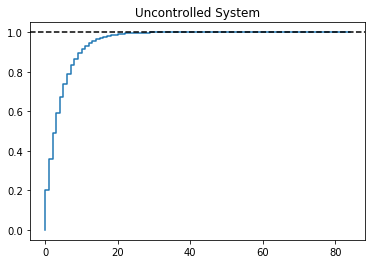

+--------------------------------------------+------------------------------+-----------------------------+
|                                            | Integral Absolute Error(IAE) | Integral Squared Error(ISE) |
+--------------------------------------------+------------------------------+-----------------------------+
|      b-w controlled System responses       |          6.974E-05           |          7.717E-09          |
|            b-w Control signals             |          9.863E-05           |          1.426E-08          |
|             b-w Error signals              |          6.074E-05           |          6.215E-09          |
| b-w controlled System responses with noise |          6.945E-05           |          6.143E-09          |
+--------------------------------------------+------------------------------+-----------------------------+


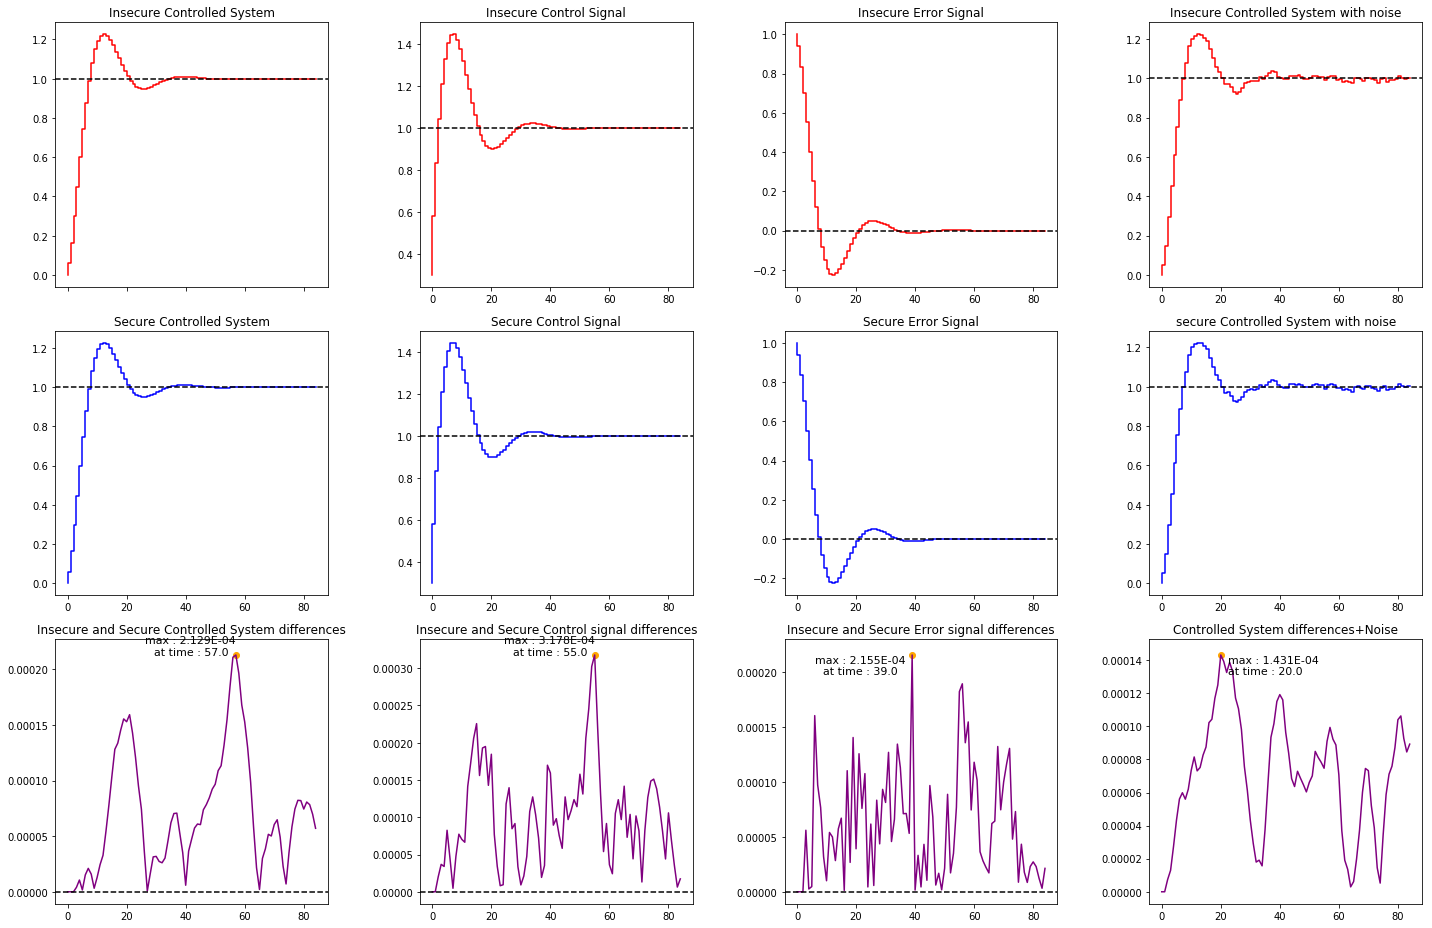

In [3]:
 ##using multiplication (ADDITION ACCURACY : SCALE,  MULT ACCURACY: SCALE/2)   ###########CONTROL###########+ rnd NOISE### coeff of e in u computing is publickly known
###
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal

#number of parties(servers) and finite field and number of samples
server=3 #set number of servers
t=1 #set shamir threshold
sampling=85
F=GF(next_prime(2^50))
scale=4 #MUST BE EVEN
print('field cardinality : {0}'.format(F.cardinality()))
mu=0  #Mean (“centre”) of the distribution
sigma=0.01 #Standard deviation (spread or “width”) of the distribution. Must be non-negative
#initial values
rk,ek,srk,sek,ekn,rkn,eksn,srkn=1,1,1,1,1,1,1,1
ycont,yuncont,ukminus1,yconts,yunconts,ukminus1s,ycontn,ukminus1n,ycontsn,ukminus1sn=0,0,0,0,0,0,0,0,0,0
insecureU,secureU,Yuncont,Ycont,YNcont,YNscont,Yscont,E,SE=[],[],[0],[0],[0],[0],[0],[],[]
noise=np.random.normal(mu,sigma,sampling)

#UNCONTROLLED SYSTEM
for i in range(sampling):
    yuncont=0.8*yuncont+0.2
    Yuncont.append(yuncont)
    
#INSECURE Cntrol    
tic=time.time()
for i in range(sampling):
    ek = rk-ycont
    uk = ukminus1 + 0.3*ek
    ycont=0.8*ycont + 0.2*uk 
    ukminus1 = uk
    Ycont.append(ycont)
    insecureU.append(uk)
    E.append(ek)
toc=time.time()

#INSECURE Cntrol+Noise    
for i in range(sampling):
    ekn = rkn-ycontn
    ukn = ukminus1n + 0.3*ekn
    ycontn=0.8*ycontn + 0.2*ukn + noise[i]
    ukminus1n = ukn
    YNcont.append(ycontn)


#SECURE Cntrol + Noise (sytem is controlled by parties securely)
r=sss.basispoly(F,server)
#sharing initial value
ukminus1sn=sss.share(F,ukminus1sn,t,server,scale)
srkn=sss.share(F,srkn,t,server,scale)
ycontsn0=sss.share(F,-ycontsn,t,server,scale)
ecoeffn=sss.share(F,0.3,t,server,scale)
for i in range(sampling):
    #cloud computing part
    eksn =shamirproc.add(F,srkn,ycontsn0,t,server,scale)
    #control law (Computed by n servers)
    uksn = shamirproc.add(F,ukminus1sn,shamirproc.mult(F,ecoeffn,eksn,t,server,scale),t,server,scale)
    #center server computing part
    ycontsn=0.8*ycontsn+0.2*(sss.rec(F,uksn,r,scale)) + noise[i]
    ycontsn0=sss.share(F,-ycontsn,t,server,scale)
    ukminus1sn = uksn
    YNscont.append(ycontsn)


#SECURE Cntrol (sytem is controlled by parties securely)
r=sss.basispoly(F,server)
ukminus1s=sss.share(F,ukminus1s,t,server,scale)
srk=sss.share(F,srk,t,server,scale)
yconts0=sss.share(F,-yconts,t,server,scale)
ecoeff=sss.share(F,0.3,t,server,scale)
tics=time.time()
for i in range(sampling):
    eks =shamirproc.add(F,srk,yconts0,t,server,scale) 
    #control law (Computed by n servers)
    uks = shamirproc.add(F,ukminus1s,shamirproc.mult(F,ecoeff,eks,t,server,scale),t,server,scale) 
    yconts=0.8*yconts+0.2*(sss.rec(F,uks,r,scale))
    yconts0=sss.share(F,-yconts,t,server,scale)
    ukminus1s = uks
    Yscont.append(yconts)
    secureU.append(sss.rec(F,uks,r,scale))
    SE.append(sss.rec(F,eks,r,scale))
tocs=time.time()
print('running time of insecure controller: {0}'.format(toc-tic))
print('running time of secure controller: {0}'.format(tocs-tics))
print('running time of secure /running time of insecure : {0}'.format((tocs-tics)/(toc-tic)))
Ycont.pop()
YNcont.pop()
Yscont.pop()
YNscont.pop()
Yuncont.pop()
srk=srkn=rk
#error will be very smaller in the end of secure case because secure conroller compute control signal up to 3 decimal places


samples=[]
for i in range(sampling):
    samples.append(i)

##UNCONTROLLED SYSTEM_STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'UNCONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
funcont = interp1d(Yuncont,samples) #interpolating time with respect to output values
f2uncont = interp1d(samples,Yuncont) #interpolating output values with respect to time
#stepresponse of sys
uncontau = funcont(0.632)
uncontrising=2.2*uncontau
uncontsettling=4*uncontau
tau=print('uncontrolled system constant time :{0}'.format(uncontau))
risingtime = print('uncontrolled system risingtime :{0}'.format(uncontrising)) 
settlingtime = print('uncontrolled system settlingtime :{0}'.format(uncontsettling))
if max(Yuncont)>rk:
    peakampun=round(max(Yuncont),2)
    overshootun=round(((max(Yuncont)-rk)/rk)*100,1)
    peaktimeun=round(funcont(max(Yuncont)),2)
    print('uncontrolled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakampun,overshootun,peaktimeun))

##INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fcont = interp1d(Ycont,samples) 
f2cont=interp1d(samples,Ycont) 
#stepresponse of sys
contau = fcont(0.632*rk)
contrising = fcont(0.85*rk)-fcont(0.05*rk)
contsettling = fcont(0.98*rk)
tau=print('Insecure controlled system constant time :{0}'.format(contau))
risingtime = print('Insecure controlled system risingtime :{0}'.format(contrising)) 
settlingtime = print('Insecure controlled system settlingtime :{0}'.format(contsettling))
if max(Ycont)>rk:
    peakamp=round(max(Ycont),2)
    overshoot=round(((max(Ycont)-rk)/rk)*100,1)
    peaktime=round(fcont(max(Ycont)),2)
    print('Insecure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamp,overshoot,peaktime))

##SECURE STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fscont = interp1d(Yscont,samples)
f2scont = interp1d(samples,Yscont)
#stepresponse of sys
scontau = fscont(0.632*srk)
scontrising = fscont(0.85*srk)-fscont(0.05*srk)
scontsettling = fscont(0.98*srk)
tau=print('Secure controlled system constant time :{0}'.format(scontau))
risingtime = print('Secure controlled system risingtime :{0}'.format(scontrising)) 
settlingtime = print('Secure controlled system settlingtime :{0}'.format(scontsettling))
if max(Yscont)>srk:
    peakamps=round(max(Yscont)/rk,2)
    overshoots=round(((max(Yscont)-rk)/rk)*100,1)
    peaktimes=round(fscont(max(Yscont)),2)
    print('Secure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamps,overshoots,peaktimes))


stepinfo=0 ##### put in one if you want stepinfo######
#plots
#uncontrolled sys
plt.step(samples,Yuncont)
plt.rcParams["figure.figsize"] = (7,5)
plt.title('Uncontrolled System')
plt.axhline(y = 1, color = 'black', linestyle = '--')
if stepinfo==True:
    plt.scatter(uncontrising,f2uncont(uncontrising),color = 'blue')
    plt.scatter(uncontsettling,f2uncont(uncontsettling),color = 'blue')
    plt.text(uncontrising,f2uncont(uncontrising),
             '  sys:uncontrolled\n  RisingTime : {0}'.format(round(uncontrising,2))
             ,verticalalignment='top',fontsize=11)
    plt.text(uncontsettling,f2uncont(uncontsettling),
             '  sys:uncontrolled\n  Settlingtime : {0}'.format(round(uncontsettling,2))
             ,verticalalignment='top',fontsize=11)
    if max(Yuncont)>rk:
        plt.scatter(peaktimeun,peakampun,color = 'blue')
        plt.text(peaktimeun,peakampun,
             '  sys:uncontrolled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampun,overshootun,peaktimeun),verticalalignment='top',fontsize=11) 
plt.show()

#insecure controlled sys
fig,axs = plt.subplots(3, 4)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs[0, 0].step(samples,Ycont,color = 'red')
if stepinfo==True:
    axs[0, 0].scatter(contrising,f2cont(contrising),color = 'blue')
    axs[0, 0].scatter(contsettling,f2cont(contsettling),color = 'blue')
    axs[0, 0].text(contrising,f2cont(contrising),
             '  sys:Insecure controlled\n  RisingTime : {0}'
                   .format(round(contrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 0].text(contsettling,f2cont(contsettling),
             '  sys:Insecure controlled\n  Settlingtime : {0}'
                   .format(round(contsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycont)>rk:
        axs[0, 0].scatter(peaktime,peakamp,color = 'blue')
        axs[0, 0].text(peaktime,peakamp,
             '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0, 0].set_title('Insecure Controlled System')
axs[0, 0].axhline(y = rk, color = 'black', linestyle = '--')
axs[0, 0].label_outer()

#secure controlled sys
axs[1, 0].step(samples,Yscont,color = 'blue')
if stepinfo==True:
    axs[1, 0].scatter(scontrising,f2scont(scontrising),color = 'red')
    axs[1, 0].scatter(scontsettling,f2scont(scontsettling),color = 'red')
    axs[1, 0].text(scontrising,f2scont(scontrising),
             '  sys:Secure controlled\n  RisingTime : {0}'
                   .format(round(scontrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 0].text(scontsettling,f2scont(scontsettling),
             '  sys:Secure controlled\n  Settlingtime : {0}'
                   .format(round(scontsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycont)>rk:
        axs[1, 0].scatter(peaktimes,peakamps,color = 'red')
        axs[1, 0].text(peaktimes,peakamps,
             '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1, 0].set_title('Secure Controlled System')
axs[1, 0].axhline(y = rk, color = 'black', linestyle = '--')
#control signal
axs[0, 1].step([i for i in range(len(insecureU))],insecureU,color = 'red')
axs[0, 1].set_title('Insecure Control Signal')
axs[0, 1].axhline(y = rk, color = 'black', linestyle = '--')
axs[1, 1].step([i for i in range(len(secureU))],secureU,color = 'blue')
axs[1, 1].set_title('Secure Control Signal')
axs[1, 1].axhline(y = rk, color = 'black', linestyle = '--')
#Error signal
axs[0, 2].step([i for i in range(len(E))],E,color = 'red')
axs[0, 2].set_title('Insecure Error Signal')
axs[0, 2].axhline(y = 0, color = 'black', linestyle = '--')
axs[1, 2].step([i for i in range(len(SE))],SE,color = 'blue')
axs[1, 2].set_title('Secure Error Signal')
axs[1, 2].axhline(y = 0, color = 'black', linestyle = '--')

#Insecure and Secure Controlled System difference
Ydiffrence=abs(np.array(Yscont)-np.array(Ycont))
fYdiff=interp1d(Ydiffrence,samples) 
axs[2, 0].plot(samples,Ydiffrence,color = 'purple')
axs[2, 0].set_title('Insecure and Secure Controlled System differences')
axs[2, 0].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 0].scatter(fYdiff(max(Ydiffrence)),max(Ydiffrence),color = 'orange')
axs[2, 0].text(fYdiff(max(Ydiffrence)),max(Ydiffrence),
            '  max : {0}\n  at time : {1}  '.format('%.3E' % Decimal(str(max(Ydiffrence)))
            ,fYdiff(max(Ydiffrence))),horizontalalignment='right',fontsize=11)
#axs[2, 0].set_ylim([0, 0.0012])

#Insecure and Secure Control signal difference
Udiffrence=abs(np.array(secureU)-np.array(insecureU))
fUdiff=interp1d(Udiffrence,samples) 
axs[2, 1].plot(samples,abs(np.array(secureU)-np.array(insecureU)),color = 'purple')
axs[2, 1].set_title('Insecure and Secure Control signal differences')
axs[2, 1].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 1].scatter(fUdiff(max(Udiffrence)),max(Udiffrence),color = 'orange')
axs[2, 1].text(fUdiff(max(Udiffrence)),max(Udiffrence),
            '  max : {0}\n  at time : {1}  '.format('%.3E' % Decimal(str(max(Udiffrence)))
            ,fUdiff(max(Udiffrence))),horizontalalignment='right',fontsize=11)
#axs[2, 1].set_ylim([0, 0.0012])

#Insecure and Secure Error signal difference
Ediffrence=abs(np.array(SE)-np.array(E))
fEdiff=interp1d(Ediffrence,samples)
axs[2, 2].plot(samples,abs(np.array(SE)-np.array(E)),color = 'purple')
axs[2, 2].set_title('Insecure and Secure Error signal differences')
axs[2, 2].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 2].scatter(fEdiff(max(Ediffrence)),max(Ediffrence),color = 'orange')
axs[2,2].text(fEdiff(max(Ediffrence)),max(Ediffrence),
            '  max : {0}  \n  at time : {1}    '.format('%.3E' % Decimal(str(max(Ediffrence)))
            ,fEdiff(max(Ediffrence))),horizontalalignment='right' ,verticalalignment='top',fontsize=11)
#axs[2, 2].set_ylim([0, 0.0012])

#insecure controlled sys+Noise
axs[0, 3].step(samples,YNcont,color = 'red')
axs[0, 3].set_title('Insecure Controlled System with noise')
axs[0, 3].axhline(y = rkn, color = 'black', linestyle = '--')

#secure controlled sys+Noise
axs[1, 3].step(samples,YNscont,color = 'blue')
axs[1, 3].set_title('secure Controlled System with noise')
axs[1, 3].axhline(y = srkn, color = 'black', linestyle = '--')

#Insecure and Secure Controlled System difference + noise
YNdiffrence=abs(np.array(YNcont)-np.array(YNscont))
fYNdiff=interp1d(YNdiffrence,samples)
axs[2, 3].plot(samples,abs(np.array(YNcont)-np.array(YNscont)),color = 'purple')
axs[2, 3].set_title('Controlled System differences+Noise')
axs[2, 3].scatter(fYNdiff(max(YNdiffrence)),max(YNdiffrence),color = 'orange')
axs[2,3].text(fYNdiff(max(YNdiffrence)),max(YNdiffrence),
            '  max : {0}  \n  at time : {1}    '.format('%.3E' % Decimal(str(max(YNdiffrence)))
            , fYNdiff(max(YNdiffrence))),horizontalalignment='left' ,verticalalignment='top',fontsize=11)
#axs[2, 3].set_ylim([0, 0.0012])

fig.tight_layout()
#table of defferences
sY=0
for i in Ydiffrence:
    sY+=i**2
IAEY= '%.3E' % Decimal(str(sum(Ydiffrence)/sampling))
ISEY= '%.3E' % Decimal(str(sY/sampling))
    
sU=0
for i in Udiffrence:
    sU+=i**2
IAEU= '%.3E' % Decimal(str(sum(Udiffrence)/sampling))
ISEU= '%.3E' % Decimal(str(sU/sampling))
                       
sE=0
for i in Ediffrence:
    sE+=i**2
IAEE= '%.3E' % Decimal(str(sum(Ediffrence)/sampling))
ISEE= '%.3E' % Decimal(str(sE/sampling))

sYN=0
for i in YNdiffrence:
    sYN+=i**2
IAEYN= '%.3E' % Decimal(str(sum(YNdiffrence)/sampling)) 
ISEYN= '%.3E' % Decimal(str(sYN/sampling)) 

table = [["b-w controlled System responses",IAEY,ISEY]
         ,["b-w Control signals ",IAEU,ISEU]
         ,["b-w Error signals",IAEE,ISEE]
         ,["b-w controlled System responses with noise",IAEYN,ISEYN]]

headers = ['',"Integral Absolute Error(IAE)", "Integral Squared Error(ISE)"]

print(tabulate(table, headers, tablefmt="pretty",disable_numparse=True))




In [16]:
print('\n\033[1m'+'Control signal Comparison\n'+'\033[0m')
for i,j in zip(insecureU,secureU):
   print('(insecureU,secureU) = ({0},{1})'.format(i,j))

print('\n\033[1m'+'Error signal Comparison\n'+'\033[0m')
for i,j in zip(E,SE):
   print('(insecureE,secureE) = ({0},{1})'.format(i,j))


Control signal Comparison

(insecureU,secureU) = (0.300000000000000,0.3)
(insecureU,secureU) = (0.582000000000000,0.582)
(insecureU,secureU) = (0.832680000000000,0.8327)
(insecureU,secureU) = (1.04326320000000,1.0433)
(insecureU,secureU) = (1.20913396800000,1.2092)
(insecureU,secureU) = (1.32928254432000,1.3294)
(insecureU,secureU) = (1.40564445271680,1.4058)
(insecureU,secureU) = (1.44239531227123,1.4425)
(insecureU,secureU) = (1.44525228117850,1.4453)
(insecureU,secureU) = (1.42082271943361,1.4209)
(insecureU,secureU) = (1.37602970687168,1.3761)
(insecureU,secureU) = (1.31763351440983,1.3177)
(insecureU,secureU) = (1.25185854957577,1.2519)
(insecureU,secureU) = (1.18412706473397,1.1842)
(insecureU,secureU) = (1.11889425297649,1.1189)
(insecureU,secureU) = (1.05957434839192,1.0596)
(insecureU,secureU) = (1.00854396382075,1.0086)
(insecureU,secureU) = (0.967207018334564,0.9673)
(insecureU,secureU) = (0.936105040845544,0.9362)
(insecureU,secureU) = (0.915057156403595,0.9151)
(insecureU

In [1]:
from shamirproc import *
F=GF(next_prime(2^54))
a=3.236
b=-200.36589
t=1
print(a*b)
n=6
scale=6
r=sss.basispoly(F,n)
sss.rec(F,mult(F,a,b,t,n,scale),r,scale)


-648.384020040000


-648.38114

In [2]:
4e-5*5

0.000200000000000000

In [135]:
error=[0,1,2,3,4,5]
error.pop(0)
erro

[1, 2, 3, 4, 5]

In [139]:
g=np.array([1,2,3])
np.resize(g, g.size - 1)

array([1, 2])

In [27]:
import numpy as np
n=np.array([1,2,3])
m=np.array([4,5,6])
g=[n,m]
len(g)

2